# BKPyV ODE Simulation Demonstration

This notebook exercises the **canonical BKPyV ODE engine** (`simulator: bkpyv_ode`,
`BKPyVODESimulator`) through the standard experiment path (`ExperimentRunner`
+ versioned YAML configs). It reproduces the two headline mechanistic axes:

1. **Drug exposure** — tacrolimus vs sirolimus effects on viral load dynamics.
2. **NCCR variant** — archetype (persistent) vs rearranged (early-gene-biased
   hypothesis-testing scenario) control region.

**Units and honesty notes**

- All times are **model days** (ODE rate constants are per day).
- `viral_load` is a **normalized model quantity** (0–1), not copies/mL.
- Where copies/mL are shown, they use an **assumption-labelled anchor bridge**
  for hypothesis visualization only — not a calibration to patient data.
- The S-phase replication gate is driven by **host cell-cycle state**, not by
  T antigen level.
- Direction-of-effect comparisons are supported; absolute magnitudes are
  hypothesis-generating, not clinical predictions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from vcm.experiments.runner import ExperimentRunner
from vcm.plugins.transplant.bk_polyomavirus import BKPolyomavirusPlugin
from vcm.clinical.viral_load_mapper import ClinicalViralLoadMapper, ClinicalThresholds

# nbconvert executes with cwd = the notebook's directory; fall back to cwd
# if the notebook is ever executed from the repository root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "configs").is_dir() else Path.cwd().parent
CONFIG_DIR = REPO_ROOT / "configs"

BKPolyomavirusPlugin().register()
runner = ExperimentRunner()
print("configs dir:", CONFIG_DIR.relative_to(REPO_ROOT))

configs dir: configs


## 1. Baseline infection run

Load the committed `bkpyv_ode_infection` configuration and run it through
`ExperimentRunner.run_experiment` — the same path the CLI `vcm run` uses.

In [2]:
def extract_trajectory(result):
    """Pull (days, normalized viral load) out of a SimulationResult."""
    times = [step.timestamp for step in result.steps]
    loads = [
        step.cell_state.metadata.get("viral_load", 0.0) for step in result.steps
    ]
    return times, loads


baseline_cfg = runner.load_config(CONFIG_DIR / "bkpyv_ode_infection.yaml")
baseline = runner.run_experiment(baseline_cfg)
t_base, v_base = extract_trajectory(baseline)

print(f"simulator={baseline_cfg.simulator}  time_unit={baseline_cfg.time_unit}")
print(f"steps={len(baseline.steps)}  horizon={baseline_cfg.simulation_length} days")
print(f"peak normalized load={max(v_base):.4f} at day {t_base[v_base.index(max(v_base))]:.0f}")
print(f"endpoint normalized load={v_base[-1]:.4f}")

simulator=bkpyv_ode  time_unit=days
steps=101  horizon=100.0 days
peak normalized load=3.0030 at day 15
endpoint normalized load=0.4234


## 2. Drug-exposure comparison

Run the committed tacrolimus and sirolimus scenario configs and overlay the
trajectories. Tacrolimus is expected to raise replication (calcineurin
inhibition weakens immune control); sirolimus is expected to reduce
S-phase-coupled production (mTOR inhibition). This is a **direction-of-effect**
comparison inside the same mechanistic model.

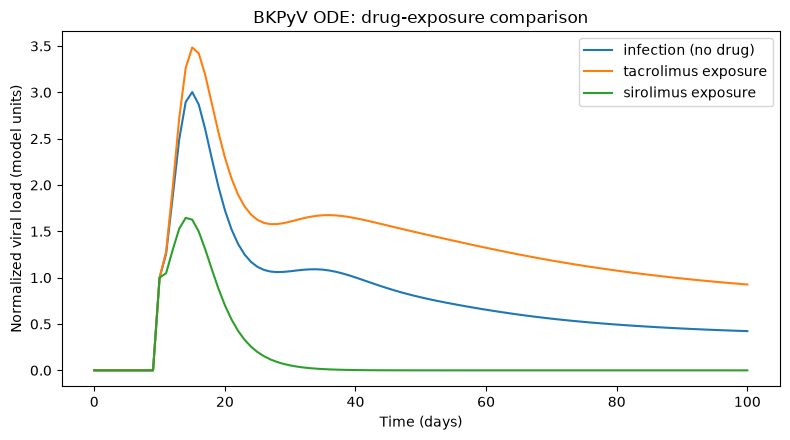

,scenario,peak_load,endpoint_load
0,infection,3.002978,4.234320e-01
1,tacrolimus,3.484108,9.264692e-01
2,sirolimus,1.645360,6.830239e-13


In [3]:
tac_cfg = runner.load_config(CONFIG_DIR / "bkpyv_ode_tacrolimus.yaml")
siro_cfg = runner.load_config(CONFIG_DIR / "bkpyv_ode_sirolimus.yaml")
tac = runner.run_experiment(tac_cfg)
siro = runner.run_experiment(siro_cfg)
t_tac, v_tac = extract_trajectory(tac)
t_siro, v_siro = extract_trajectory(siro)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_base, v_base, label="infection (no drug)")
ax.plot(t_tac, v_tac, label="tacrolimus exposure")
ax.plot(t_siro, v_siro, label="sirolimus exposure")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Normalized viral load (model units)")
ax.set_title("BKPyV ODE: drug-exposure comparison")
ax.legend()
fig.tight_layout()
plt.show()

summary = pd.DataFrame(
    {
        "scenario": ["infection", "tacrolimus", "sirolimus"],
        "peak_load": [max(v_base), max(v_tac), max(v_siro)],
        "endpoint_load": [v_base[-1], v_tac[-1], v_siro[-1]],
    }
)
summary

## 3. NCCR variant comparison

The rearranged NCCR is a **hypothesis-testing scenario** (early-gene bias,
reduced capsid expression), not a prevalence estimate. The variant flows into
the run through `create_initial_state`, which the runner forwards into the
simulator configuration.

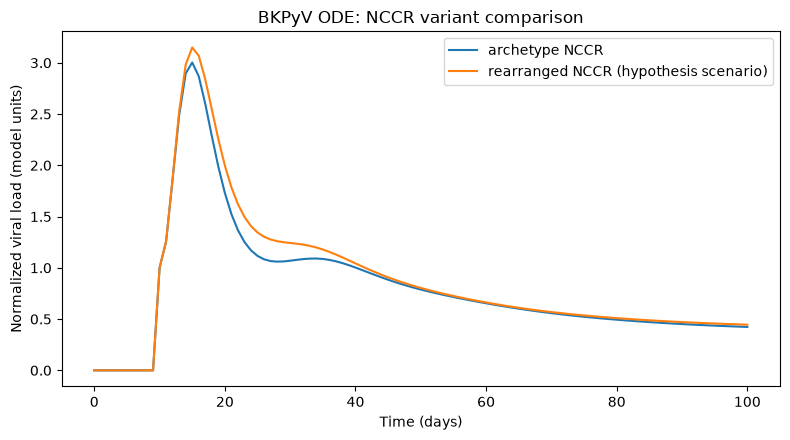

archetype peak=3.0030  rearranged peak=3.1492


In [4]:
plugin = BKPolyomavirusPlugin()
rearranged_state = plugin.create_initial_state({"nccr_variant": "rearranged"})
rearranged = runner.run_experiment(baseline_cfg, initial_state=rearranged_state)
t_re, v_re = extract_trajectory(rearranged)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_base, v_base, label="archetype NCCR")
ax.plot(t_re, v_re, label="rearranged NCCR (hypothesis scenario)")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Normalized viral load (model units)")
ax.set_title("BKPyV ODE: NCCR variant comparison")
ax.legend()
fig.tight_layout()
plt.show()

print(f"archetype peak={max(v_base):.4f}  rearranged peak={max(v_re):.4f}")

## 4. Assumption-labelled clinical bridge

For reviewer intuition we can map normalized load to copies/mL through a
**fixed anchor scale**. This is explicitly an assumption-labelled bridge for
hypothesis visualization — it is *not* a calibration to measured patient
loads, and the x-axis remains model days.

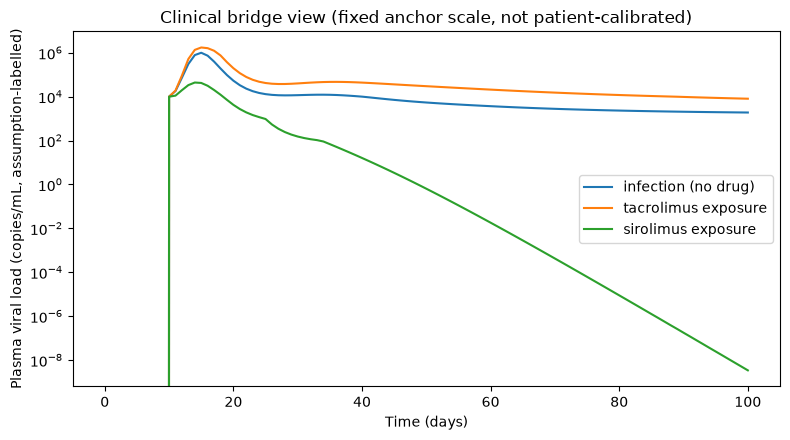

baseline peak bridge load=1003434 copies/mL -> treatment


In [5]:
mapper = ClinicalViralLoadMapper()
plasma_base = [mapper.normalized_to_copies(v) for v in v_base]
plasma_tac = [mapper.normalized_to_copies(v) for v in v_tac]
plasma_siro = [mapper.normalized_to_copies(v) for v in v_siro]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_base, plasma_base, label="infection (no drug)")
ax.plot(t_tac, plasma_tac, label="tacrolimus exposure")
ax.plot(t_siro, plasma_siro, label="sirolimus exposure")
ax.set_yscale("log")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Plasma viral load (copies/mL, assumption-labelled)")
ax.set_title("Clinical bridge view (fixed anchor scale, not patient-calibrated)")
ax.legend()
fig.tight_layout()
plt.show()

peak = max(plasma_base)
print(f"baseline peak bridge load={peak:.0f} copies/mL -> "
      f"{ClinicalThresholds.get_risk_category(peak)}")

## Interpretation and caveats

- The ODE engine produces smooth day-scale trajectories; the legacy discrete
  `bkpyv_specific` simulator uses hourly steps and is kept for backward
  compatibility only.
- Tacrolimus/sirolimus effects enter as mechanistic parameter modifiers;
  the comparison supports **direction**, not clinical magnitude.
- The copies/mL panel is an **assumption-labelled anchor bridge** — hypothesis
  visualization only, not patient calibration.
- Rearranged-NCCR outputs are falsifiable scenario comparisons, not
  prevalence estimates.

See `docs/BKPYV_MODEL_CARD.md` for the full assumption ledger.